/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


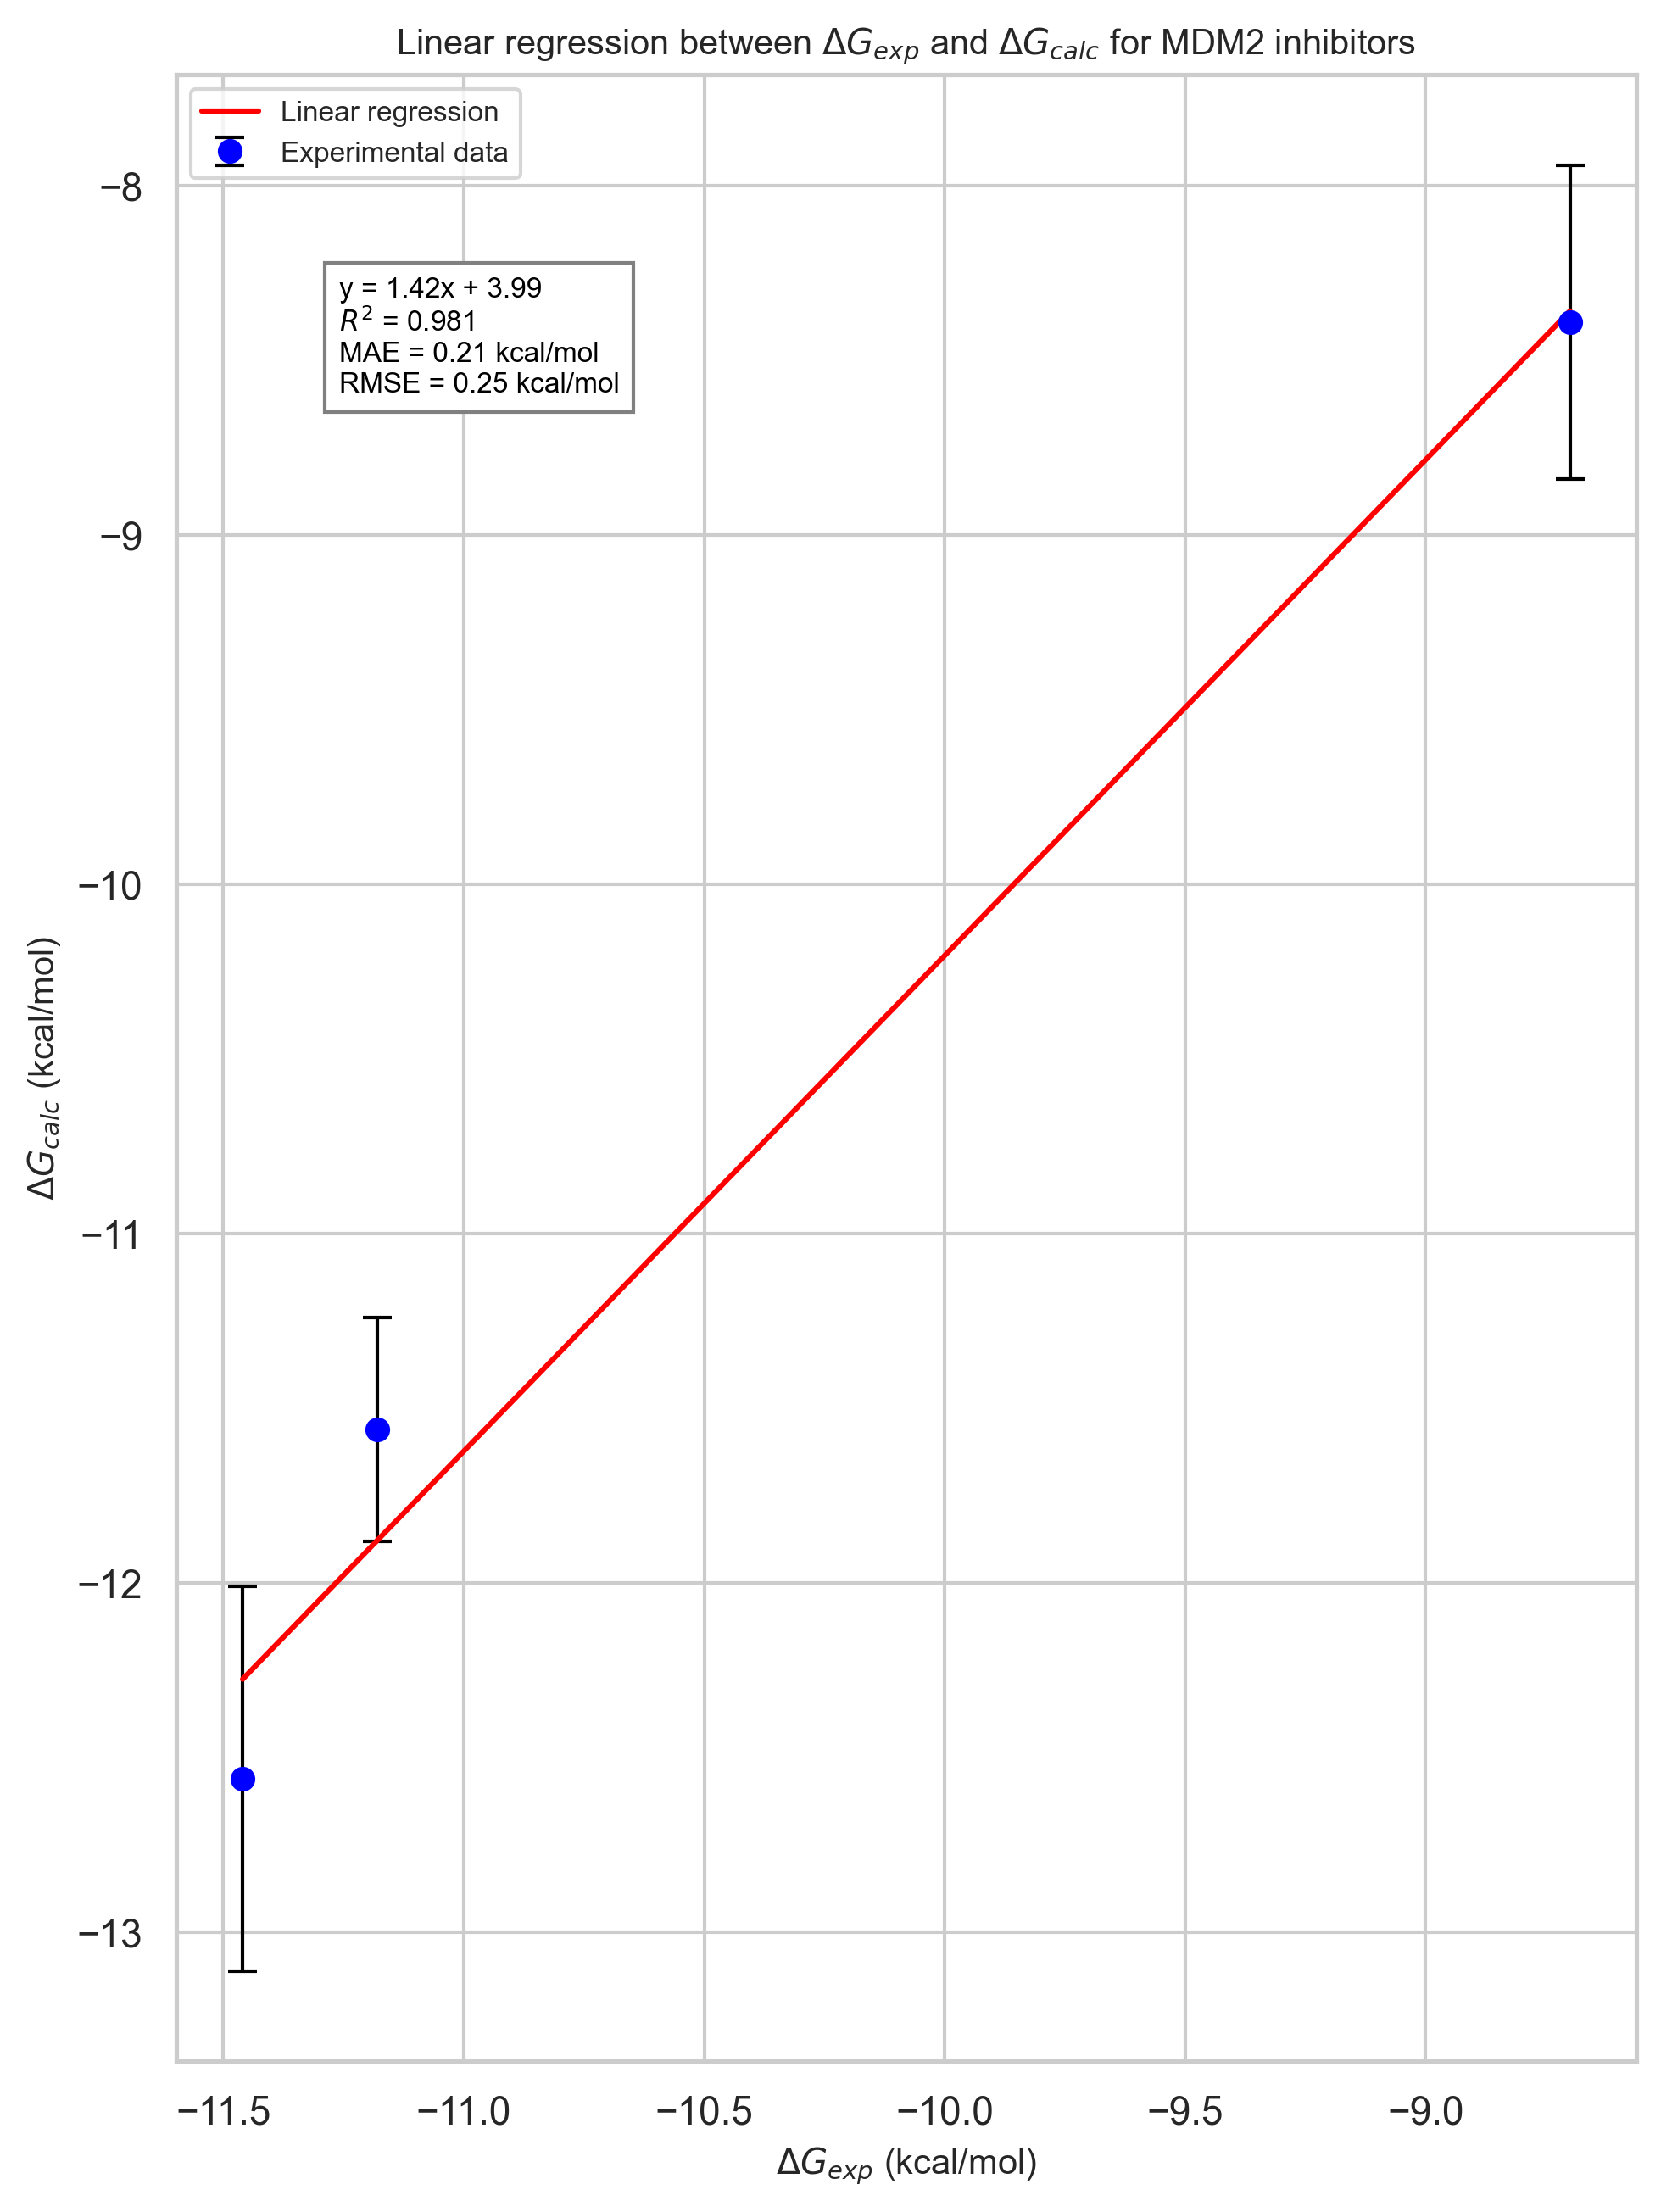

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns

# Input data
DG_exp = np.array([-8.7, -11.18, -11.46])
DG_calc = np.array([-8.39, -11.56, -12.56])
std_dev = np.array([0.45, 0.32, 0.55])  # Standard deviations for each ΔG_calculated

# Linear regression
model = LinearRegression()
X = DG_exp.reshape(-1, 1)
y = DG_calc
model.fit(X, y)
y_pred = model.predict(X)

# Regression metrics
slope = model.coef_[0]
intercept = model.intercept_
r_squared = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = mean_squared_error(y, y_pred, squared=False)

# Plot configuration: 170 mm wide (full page), 225 mm tall max
plt.figure(figsize=(170 / 25.4, 225 / 25.4), dpi=300)

sns.set(style="whitegrid")

# Plot with error bars
plt.errorbar(DG_exp, DG_calc, yerr=std_dev, fmt='o', color='blue',
             ecolor='black', elinewidth=1, capsize=4, label='Experimental data')

# Regression line
plt.plot(DG_exp, y_pred, color='red', linewidth=1.5, label='Linear regression')

# Annotation
equation = f'y = {slope:.2f}x + {intercept:.2f}'
metrics = f'$R^2$ = {r_squared:.3f}\nMAE = {mae:.2f} kcal/mol\nRMSE = {rmse:.2f} kcal/mol'
plt.text(min(DG_exp)+0.2, max(DG_calc)-0.2, equation + '\n' + metrics,
         fontsize=8, color='black', bbox=dict(facecolor='white', edgecolor='gray'))

# Axis labels and title
plt.xlabel(r'$\Delta G_{exp}$ (kcal/mol)', fontsize=10)
plt.ylabel(r'$\Delta G_{calc}$ (kcal/mol)', fontsize=10)
plt.title('Linear regression between $\Delta G_{exp}$ and $\Delta G_{calc}$ for MDM2 inhibitors', fontsize=10)
plt.legend(fontsize=8)
plt.tight_layout()

# Save high-resolution figure
plt.savefig('DG_regression_with_errorbars.png', dpi=300)
plt.show()
